# Callable Bond Pricing — Ho-Lee Binomial Tree

## Overview

A **callable bond** is a fixed-rate bond in which the issuer retains the right to redeem
the bond at par on specified future dates (coupon payment dates on or after `call_start`).

### Embedded call option

From the investor's perspective the callable bond is equivalent to:

$$P_{\text{callable}} = P_{\text{straight}} - C_{\text{call}}$$

where $C_{\text{call}}$ is the value of the embedded call option the investor has *sold* to
the issuer.  The issuer exercises when rates fall and the bond's fair value exceeds par,
allowing them to refinance at cheaper rates.  This caps the upside for the investor.

### Option-adjusted spread (OAS)

The **option-adjusted spread** is the constant spread added to the risk-free curve that
makes the model price equal to the market price, after removing the option component.  It
reflects the credit spread stripped of the optionality distortion:

$$\text{OAS}: \quad P_{\text{market}} = \text{PV of cash flows discounted at } z(t) + \text{OAS}$$

### Ho-Lee model

The short rate follows:

$$r(t+\Delta t) = r(t) + \theta(t)\,\Delta t + \sigma\,\Delta W$$

where $\theta(t)$ is calibrated to match the initial discount curve and $\sigma$ is the
constant short-rate volatility.  In the binomial tree (risk-neutral probability $p=0.5$
at each node), the rate at step $i$, node $j$ is:

$$r_{i,j} = f(i\,\Delta t) + j\,\sigma\,\sqrt{\Delta t}$$

where $f(t)$ is the instantaneous forward rate from the bootstrapped curve.

Backward induction values the bond at each node; at call-eligible nodes the issuer calls
at par whenever the continuation value exceeds face.

## 1. Imports and Curve Building

Bootstrap a discount curve from market instruments (value date: 2025-01-01).

In [1]:
from neon.lib.fixed_income.bond import Bond
from neon.lib.fixed_income.callable_bond import CallableBond
from neon.lib.fixed_income.bootstrapping.deposit import Deposit
from neon.lib.fixed_income.bootstrapping.swap import Swap
from neon.lib.fixed_income.bootstrapping.bootstrapper import CurveBootstrapper
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline

VALUE_DATE = "20250101"
SETTLE     = "20250101"
ISSUE      = "20250101"
MATURITY   = "20350101"
CALL_START = "20270101"

instruments = [
    Deposit(VALUE_DATE, "20250401", rate=0.04),
    Swap(VALUE_DATE, "20260101", fixed_rate=0.044, coupon_freq=2),
    Swap(VALUE_DATE, "20270101", fixed_rate=0.046, coupon_freq=2),
    Swap(VALUE_DATE, "20300101", fixed_rate=0.048, coupon_freq=2),
    Swap(VALUE_DATE, "20350101", fixed_rate=0.050, coupon_freq=2),
]

bootstrapper = CurveBootstrapper(value_date=VALUE_DATE, instruments=instruments)
curve = bootstrapper.build()

print("Curve dates     :", curve.dates)
print("Zero rates      :", [f"{r:.4%}" for r in curve.zero_rates])

Curve dates     : ['20250401', '20260101', '20270101', '20300101', '20350101']
Zero rates      : ['4.0354%', '4.3784%', '4.5803%', '4.9419%', '5.2764%']


## 2. Price Callable vs Non-Callable Bond

Both bonds: 5 % semi-annual coupon, 10-year maturity.  
The callable version can be called at par from **2027-01-01** onward on each coupon date.

$$C_{\text{call}} = P_{\text{straight}} - P_{\text{callable}}$$

In [2]:
SIGMA = 0.01  # baseline short-rate volatility

straight = Bond(
    issue_date=ISSUE,
    maturity_date=MATURITY,
    coupon_rate=0.05,
    coupon_freq=2,
)

callable_bond = CallableBond(
    issue_date=ISSUE,
    maturity_date=MATURITY,
    coupon_rate=0.05,
    coupon_freq=2,
    call_start=CALL_START,
    vol=SIGMA,
)

# Non-callable bond: price by discounting cash flows on the curve
straight_dirty = straight.dirty_price_from_curve(SETTLE, curve)
straight_ai    = straight.accrued_interest(SETTLE)
straight_clean = straight_dirty - straight_ai

# Callable bond: price via Ho-Lee binomial tree
callable_clean = callable_bond.clean_price_from_tree(SETTLE, curve)
callable_dirty = callable_bond.dirty_price_from_tree(SETTLE, curve)

call_option_value = straight_clean - callable_clean

print(f"Non-callable clean price : {straight_clean:.4f}")
print(f"Callable clean price     : {callable_clean:.4f}")
print(f"Embedded call option     : {call_option_value:.4f}")
print()
print(f"Non-callable dirty price : {straight_dirty:.4f}")
print(f"Callable dirty price     : {callable_dirty:.4f}")
print(f"Accrued interest         : {straight_ai:.4f}")

Non-callable clean price : 97.7411
Callable clean price     : 59.2236
Embedded call option     : 38.5175

Non-callable dirty price : 97.7411
Callable dirty price     : 59.2236
Accrued interest         : 0.0000


### Interpretation

| Metric | Value |
|---|---|
| Non-callable clean price | priced to curve |
| Callable clean price | tree-priced with call feature |
| Embedded call option value | `straight − callable` |

The callable bond trades below the straight bond because the investor has granted the
issuer a call option.  Higher interest-rate volatility increases the option value and
further depresses the callable price.

## 3. Effect of Volatility (sigma) on Callable Price

Sweep $\sigma$ from 0.5 % to 3 % and record the callable clean price and implied call
option value at each level.  The non-callable price (curve-based) is independent of
$\sigma$.

In [3]:
sigmas = np.linspace(0.005, 0.03, 20)

callable_prices = []
option_values   = []

for sigma in sigmas:
    cb = CallableBond(
        issue_date=ISSUE,
        maturity_date=MATURITY,
        coupon_rate=0.05,
        coupon_freq=2,
        call_start=CALL_START,
        vol=sigma,
    )
    cp = cb.clean_price_from_tree(SETTLE, curve)
    callable_prices.append(cp)
    option_values.append(straight_clean - cp)

print(f"Straight bond clean price (fixed): {straight_clean:.4f}")
print()
print(f"{'Sigma':>8}  {'Callable':>10}  {'Call Option':>12}")
print("-" * 36)
for s, cp, ov in zip(sigmas, callable_prices, option_values):
    print(f"{s:>8.3%}  {cp:>10.4f}  {ov:>12.4f}")

Straight bond clean price (fixed): 97.7411

   Sigma    Callable   Call Option
------------------------------------
  0.500%     75.5296       22.2115
  0.632%     70.6685       27.0726
  0.763%     66.2385       31.5026
  0.895%     62.1990       35.5421
  1.026%     58.5131       39.2280
  1.158%     55.1477       42.5934
  1.289%     52.0729       45.6682
  1.421%     49.2614       48.4797
  1.553%     46.6889       51.0522
  1.684%     44.3333       53.4079
  1.816%     42.1744       55.5667
  1.947%     40.1942       57.5469
  2.079%     38.3764       59.3647
  2.211%     36.7061       61.0350
  2.342%     35.1697       62.5714
  2.474%     33.7546       63.9865
  2.605%     32.4491       65.2920
  2.737%     31.2427       66.4984
  2.868%     30.1268       67.6143
  3.000%     29.0939       68.6472


## 4. Plots

### Callable vs Non-Callable Price as a Function of Volatility

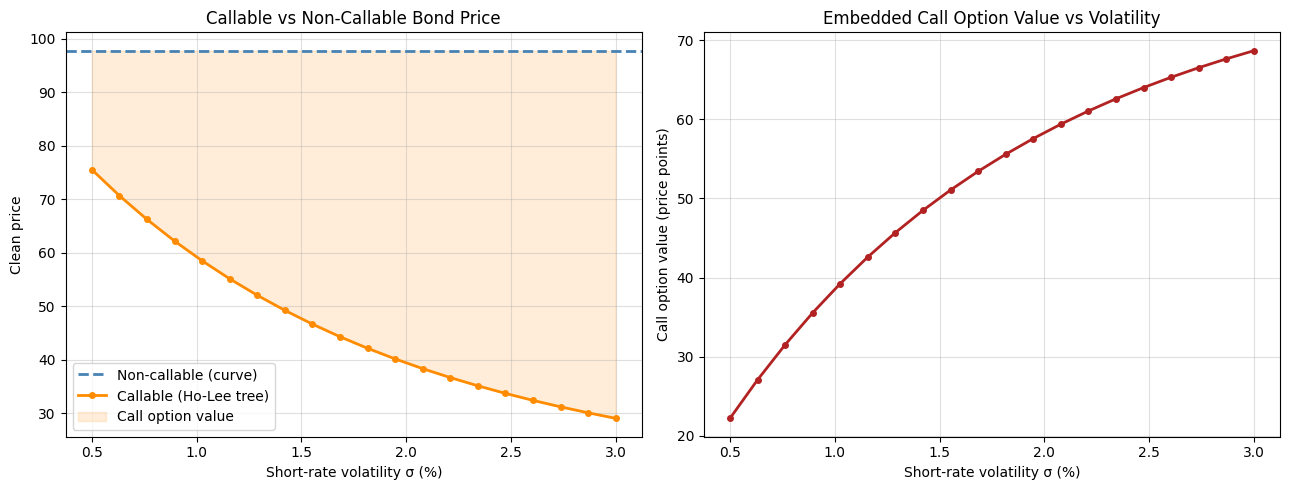

In [4]:
sigmas_pct = sigmas * 100  # express as percentage for x-axis

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# --- Left panel: prices ---
ax1.axhline(straight_clean, color="steelblue", linewidth=2,
            linestyle="--", label="Non-callable (curve)")
ax1.plot(sigmas_pct, callable_prices, color="darkorange", linewidth=2,
         marker="o", markersize=4, label="Callable (Ho-Lee tree)")
ax1.fill_between(
    sigmas_pct, callable_prices, straight_clean,
    alpha=0.15, color="darkorange", label="Call option value"
)
ax1.set_xlabel("Short-rate volatility \u03c3 (%)")
ax1.set_ylabel("Clean price")
ax1.set_title("Callable vs Non-Callable Bond Price")
ax1.legend()
ax1.grid(True, alpha=0.4)

# --- Right panel: call option value ---
ax2.plot(sigmas_pct, option_values, color="firebrick", linewidth=2,
         marker="o", markersize=4)
ax2.set_xlabel("Short-rate volatility \u03c3 (%)")
ax2.set_ylabel("Call option value (price points)")
ax2.set_title("Embedded Call Option Value vs Volatility")
ax2.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

### Key takeaways

- The **non-callable price** (dashed blue) is constant — it depends only on the discount
  curve, not on rate volatility.
- The **callable price** (orange) falls as $\sigma$ rises: higher rate vol makes the
  issuer's call option more valuable, and the investor pays for that through a lower bond
  price.
- The **embedded call option value** (right panel) is monotonically increasing in $\sigma$,
  consistent with standard option pricing intuition (more vol → more optionality).
- At $\sigma = 0$ the two prices converge: without rate uncertainty there is no option
  value — the issuer either always calls or never calls, deterministically.